<a href="https://colab.research.google.com/github/harishscse081sece/DS-project/blob/main/DS_q_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Date range
dates = pd.date_range("2025-01-01", "2025-04-30")

stores = [f"ST{str(i).zfill(2)}" for i in range(1,11)]
products = [f"P{str(i).zfill(3)}" for i in range(1,51)]

categories = [
    "Beverages",
    "Snacks",
    "Dairy",
    "Bakery",
    "Household",
    "Personal Care"
]

product_category = {
    p: np.random.choice(categories)
    for p in products
}

rows = []

for date in dates:

    holiday = "Yes" if date.weekday()==6 else "No"

    for store in stores:

        chosen_products = np.random.choice(products,15,replace=False)

        for product in chosen_products:

            category = product_category[product]

            opening_stock = np.random.randint(20,201)

            promotion = np.random.choice(
                ["Yes","No"],
                p=[0.30,0.70]
            )

            price = round(np.random.uniform(20,500),2)

            demand = np.random.randint(5,40)

            if promotion=="Yes":
                demand = int(demand*1.35)

            if holiday=="Yes":
                demand = int(demand*1.15)

            units_sold = min(opening_stock,demand)

            closing_stock = opening_stock-units_sold

            rows.append([
                date.date(),
                store,
                product,
                category,
                opening_stock,
                units_sold,
                closing_stock,
                price,
                promotion,
                holiday
            ])

df = pd.DataFrame(rows,columns=[
    "Date",
    "Store_ID",
    "Product_ID",
    "Category",
    "Opening_Stock",
    "Units_Sold",
    "Closing_Stock",
    "Price",
    "Promotion",
    "Holiday"
])

# Missing values
for i in np.random.choice(df.index,40,replace=False):
    df.at[i,"Price"]=np.nan

# Text inconsistencies
for i in np.random.choice(df.index,40,replace=False):
    df.at[i,"Promotion"]="YES"

for i in np.random.choice(df.index,40,replace=False):
    df.at[i,"Promotion"]="no"

for i in np.random.choice(df.index,30,replace=False):
    df.at[i,"Category"]=df.at[i,"Category"]+" "

# Duplicate rows
duplicates=df.sample(50,random_state=1)
df=pd.concat([df,duplicates],ignore_index=True)

df.to_csv("retail_inventory_dataset.csv",index=False)

print(df.shape)
df.head()

(18050, 10)


,Date,Store_ID,Product_ID,Category,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday
0,2025-01-01,ST01,P030,Dairy,100,9,91,399.28,No,No
1,2025-01-01,ST01,P039,Bakery,60,16,44,428.02,No,No
2,2025-01-01,ST01,P003,Dairy,181,37,144,197.99,Yes,No
3,2025-01-01,ST01,P046,Beverages,56,31,25,326.03,No,No
4,2025-01-01,ST01,P045,Household,54,18,36,77.41,No,No


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving retail_inventory_dataset.csv to retail_inventory_dataset (1).csv


In [ ]:
df = pd.read_csv("retail_inventory_dataset.csv")

df.head()

,Date,Store_ID,Product_ID,Category,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday
0,2025-01-01,ST01,P030,Dairy,100,9,91,399.28,No,No
1,2025-01-01,ST01,P039,Bakery,60,16,44,428.02,No,No
2,2025-01-01,ST01,P003,Dairy,181,37,144,197.99,Yes,No
3,2025-01-01,ST01,P046,Beverages,56,31,25,326.03,No,No
4,2025-01-01,ST01,P045,Household,54,18,36,77.41,No,No


In [ ]:
print(df.shape)

(18050, 10)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18050 entries, 0 to 18049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           18050 non-null  object 
 1   Store_ID       18050 non-null  object 
 2   Product_ID     18050 non-null  object 
 3   Category       18050 non-null  object 
 4   Opening_Stock  18050 non-null  int64  
 5   Units_Sold     18050 non-null  int64  
 6   Closing_Stock  18050 non-null  int64  
 7   Price          18010 non-null  float64
 8   Promotion      18050 non-null  object 
 9   Holiday        18050 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 1.4+ MB


In [ ]:
df.isnull().sum()

,0
Date,0
Store_ID,0
Product_ID,0
Category,0
Opening_Stock,0
Units_Sold,0
Closing_Stock,0
Price,40
Promotion,0
Holiday,0


In [ ]:
df["Price"] = df["Price"].fillna(df["Price"].median())

In [ ]:
print("Before:",len(df))

df=df.drop_duplicates()

print("After:",len(df))

Before: 18050
After: 18000


In [ ]:
df["Promotion"]=df["Promotion"].replace({
    "YES":"Yes",
    "no":"No"
})

df["Category"]=df["Category"].str.strip()

In [ ]:
print((df["Closing_Stock"]<0).sum())

0


In [ ]:
df.describe()

,Opening_Stock,Units_Sold,Closing_Stock,Price
count,18000.000000,18000.000000,18000.000000,18000.000000
mean,109.403111,24.151000,85.252111,260.773764
std,52.617248,11.657486,53.277700,138.592172
min,20.000000,5.000000,0.000000,20.060000
25%,64.000000,14.000000,39.000000,141.167500
50%,109.000000,24.000000,85.000000,260.785000
75%,155.000000,33.000000,130.000000,380.422500
max,200.000000,59.000000,195.000000,499.970000


In [ ]:
df["Category"].value_counts()

,count
Category,
Bakery,4260
Dairy,3623
Household,3211
Personal Care,2500
Beverages,2218
Snacks,2188


In [ ]:
df["Store_ID"].value_counts()

,count
Store_ID,
ST01,1800
ST02,1800
ST03,1800
ST04,1800
ST05,1800
ST06,1800
ST07,1800
ST08,1800
ST09,1800


In [ ]:
print(df["Units_Sold"].mean())

24.151


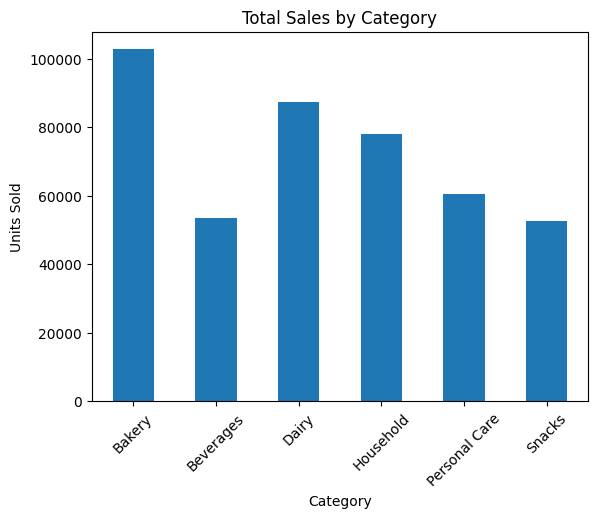

In [ ]:
category_sales=df.groupby("Category")["Units_Sold"].sum()

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

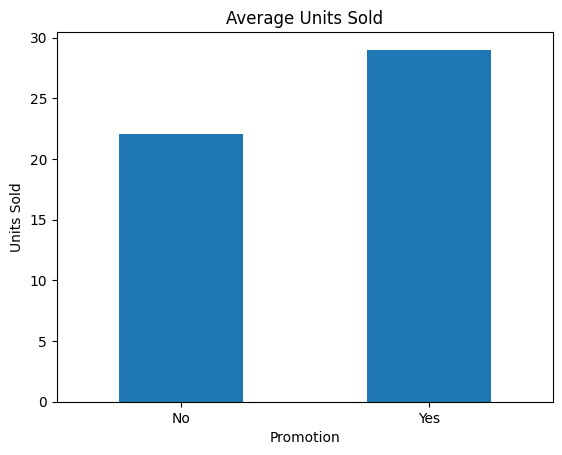

In [ ]:
promo_sales=df.groupby("Promotion")["Units_Sold"].mean()

promo_sales.plot(kind="bar")

plt.title("Average Units Sold")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.show()

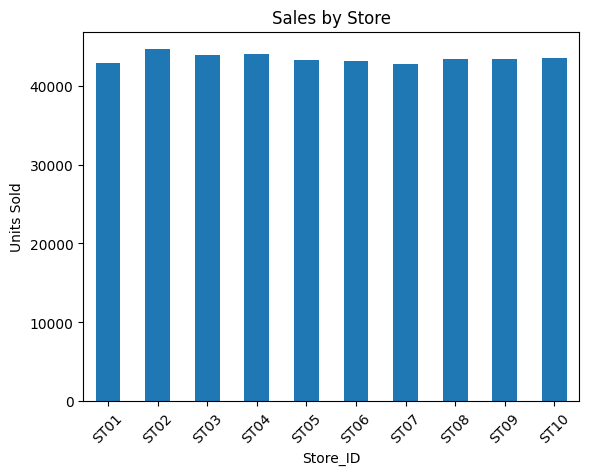

In [ ]:
store_sales=df.groupby("Store_ID")["Units_Sold"].sum()

store_sales.plot(kind="bar")

plt.title("Sales by Store")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

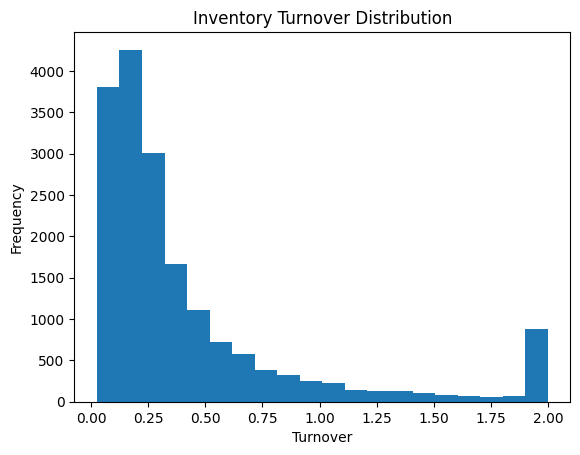

In [ ]:
df["Average_Inventory"]=(df["Opening_Stock"]+df["Closing_Stock"])/2

df["Inventory_Turnover"]=df["Units_Sold"]/df["Average_Inventory"]

plt.hist(df["Inventory_Turnover"],bins=20)

plt.title("Inventory Turnover Distribution")
plt.xlabel("Turnover")
plt.ylabel("Frequency")
plt.show()

In [ ]:
product_sales=df.groupby("Product_ID")["Units_Sold"].sum().sort_values(ascending=False)

product_sales.head(10)

,Units_Sold
Product_ID,
P047,9546
P027,9461
P031,9423
P005,9374
P006,9290
P028,9234
P036,9214
P043,9193
P046,9155


In [ ]:
fast=product_sales.head(10)

print(fast)

Product_ID
P047    9546
P027    9461
P031    9423
P005    9374
P006    9290
P028    9234
P036    9214
P043    9193
P046    9155
P035    9149
Name: Units_Sold, dtype: int64


In [ ]:
slow=product_sales.tail(10)

print(slow)

Product_ID
P010    8370
P019    8347
P018    8297
P001    8153
P017    8135
P050    8092
P007    8071
P026    7955
P004    7924
P016    7890
Name: Units_Sold, dtype: int64


In [ ]:
turnover=df.groupby("Product_ID").agg({
    "Units_Sold":"sum",
    "Average_Inventory":"mean"
})

turnover["Inventory_Turnover"]=turnover["Units_Sold"]/turnover["Average_Inventory"]

turnover.sort_values("Inventory_Turnover",ascending=False).head()

,Units_Sold,Average_Inventory,Inventory_Turnover
Product_ID,,,
P047,9546,93.583333,102.005343
P027,9461,92.786822,101.964911
P031,9423,95.453488,98.718236
P043,9193,93.402406,98.423588
P005,9374,95.295699,98.367504


In [ ]:
turnover=df.groupby("Product_ID").agg({
    "Units_Sold":"sum",
    "Average_Inventory":"mean"
})

turnover["Inventory_Turnover"]=turnover["Units_Sold"]/turnover["Average_Inventory"]

turnover.sort_values("Inventory_Turnover",ascending=False).head()

,Units_Sold,Average_Inventory,Inventory_Turnover
Product_ID,,,
P047,9546,93.583333,102.005343
P027,9461,92.786822,101.964911
P031,9423,95.453488,98.718236
P043,9193,93.402406,98.423588
P005,9374,95.295699,98.367504


In [ ]:
stockout=df.groupby("Product_ID")["Closing_Stock"].apply(lambda x:(x==0).sum())

stockout.sort_values(ascending=False).head()

,Closing_Stock
Product_ID,
P036,28
P015,26
P043,25
P005,25
P002,23


In [ ]:
promo_effect=df.groupby("Promotion")["Units_Sold"].mean()

print(promo_effect)

Promotion
No     22.086192
Yes    28.998326
Name: Units_Sold, dtype: float64


In [ ]:
increase=(promo_effect["Yes"]-promo_effect["No"])/promo_effect["No"]*100

print(f"Sales increase: {increase:.2f}%")

Sales increase: 31.30%


In [ ]:
store_comparison=df.groupby("Store_ID").agg({
    "Units_Sold":"sum",
    "Opening_Stock":"mean",
    "Closing_Stock":"mean"
})

store_comparison

,Units_Sold,Opening_Stock,Closing_Stock
Store_ID,,,
ST01,42862,108.823889,85.011667
ST02,44621,107.920000,83.130556
ST03,43902,107.250556,82.860556
ST04,44018,110.978889,86.524444
ST05,43189,110.376667,86.382778
ST06,43137,110.406667,86.441667
ST07,42755,108.234444,84.481667
ST08,43321,107.685000,83.617778
ST09,43402,111.931111,87.818889


In [ ]:
data = df.copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
enc = LabelEncoder()

for col in ["Store_ID", "Product_ID", "Category", "Promotion", "Holiday"]:
    data[col] = enc.fit_transform(data[col])

In [ ]:
data.head()

,Date,Store_ID,Product_ID,Category,Opening_Stock,Units_Sold,Closing_Stock,Price,Promotion,Holiday,Average_Inventory,Inventory_Turnover
0,2025-01-01,0,29,2,100,9,91,399.28,0,0,95.5,0.094241
1,2025-01-01,0,38,0,60,16,44,428.02,0,0,52.0,0.307692
2,2025-01-01,0,2,2,181,37,144,197.99,1,0,162.5,0.227692
3,2025-01-01,0,45,1,56,31,25,326.03,0,0,40.5,0.765432
4,2025-01-01,0,44,3,54,18,36,77.41,0,0,45.0,0.400000


In [ ]:
X = data.drop(["Units_Sold", "Date"], axis=1)

In [ ]:
print(X.head())



   Store_ID  Product_ID  Category  Opening_Stock  Closing_Stock   Price  \
0         0          29         2            100             91  399.28   
1         0          38         0             60             44  428.02   
2         0           2         2            181            144  197.99   
3         0          45         1             56             25  326.03   
4         0          44         3             54             36   77.41   

   Promotion  Holiday  Average_Inventory  Inventory_Turnover  
0          0        0               95.5            0.094241  
1          0        0               52.0            0.307692  
2          1        0              162.5            0.227692  
3          0        0               40.5            0.765432  
4          0        0               45.0            0.400000  


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y = data["Units_Sold"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (14400, 10)
Testing Features: (3600, 10)
Training Target: (14400,)
Testing Target: (3600,)


In [ ]:
model=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
mae=mean_absolute_error(y_test,y_pred)

print("MAE:",mae)

MAE: 0.12472777777777784


In [ ]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print("RMSE:",rmse)

RMSE: 0.27255957554674576


In [ ]:
r2=r2_score(y_test,y_pred)

print("R2 Score:",r2)

R2 Score: 0.99945601516925


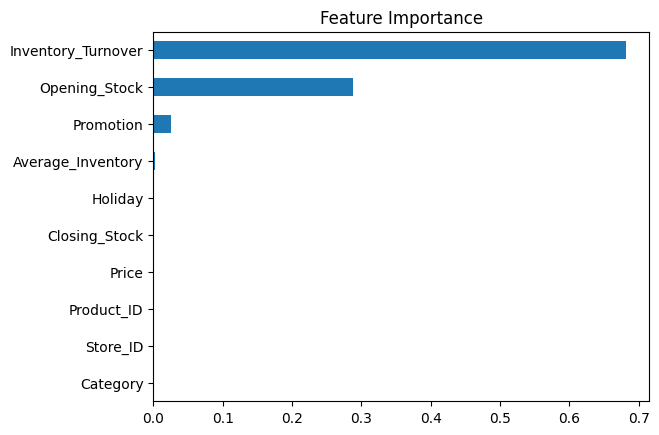

In [ ]:
importance=pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")
plt.show()

In [ ]:
print("Key Insights")
print("----------------")

print("1. Fast-moving products show the highest inventory turnover.")

print("2. Slow-moving products remain in stock longer.")

print("3. Promotions increase average sales.")

print("4. Some stores consistently sell more than others.")

print("5. Frequent stock-outs indicate understocked products.")

print("6. Opening stock strongly influences daily sales.")

print("7. Holiday sales are generally higher.")

Key Insights
----------------
1. Fast-moving products show the highest inventory turnover.
2. Slow-moving products remain in stock longer.
3. Promotions increase average sales.
4. Some stores consistently sell more than others.
5. Frequent stock-outs indicate understocked products.
6. Opening stock strongly influences daily sales.
7. Holiday sales are generally higher.


In [ ]:
print("Recommendations")
print("----------------")

print("Increase inventory for fast-moving products.")

print("Reduce stock for slow-moving products.")

print("Use promotions selectively.")

print("Improve stock planning for high-demand stores.")

print("Monitor stock-outs daily.")

print("Forecast inventory using Random Forest predictions.")

Recommendations
----------------
Increase inventory for fast-moving products.
Reduce stock for slow-moving products.
Use promotions selectively.
Improve stock planning for high-demand stores.
Monitor stock-outs daily.
Forecast inventory using Random Forest predictions.
